In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend, find_peaks
import os


In [2]:
# Constants
G = 4 * np.pi**2           # AU^3/yr^2/M_sun -- G=4pi^2 so Earth's period = 1 year at a = 1 AU
S0 = 1361                  # solar constant (W/m^2)

M_SUN = 1.0
M_EARTH = 3.003e-6         # in solar mass
M_JUPITER = 9.545e-4       # in solar mass

EARTH_R0 = 1.0             # AU
EARTH_V0 = 2 * np.pi       # AU/yr (circular orbital velocity)
EARTH_V0_ECCENTRIC = 2 * np.pi * 1.01

JUPITER_R0 = 5.2           # AU
JUPITER_V0 = 2 * np.pi / np.sqrt(JUPITER_R0)   # AU/yr

SOFTENING = 0.01           # AU (1% of Earth-Sun distance)

In [3]:
#Acceleration (2D)
def acceleration(positions, masses, softening=SOFTENING):
    N = len(masses)
    acc = np.zeros_like(positions)
    for i in range(N):
        for j in range(N):
            if i != j:
                r_vec = positions[j] - positions[i]
                r = np.linalg.norm(r_vec)
                r_soft = np.sqrt(r**2 + softening**2)
                acc[i] += G * masses[j] * r_vec / r_soft**3
    return acc

In [4]:
# Integrators
def rk4_step(positions, velocities, masses, dt):
    a1 = acceleration(positions, masses, G)
    k1_r = velocities
    k1_v = a1

    a2 = acceleration(positions + 0.5*dt*k1_r, masses, G)
    k2_r = velocities + 0.5*dt*k1_v
    k2_v = a2

    a3 = acceleration(positions + 0.5*dt*k2_r, masses, G)
    k3_r = velocities + 0.5*dt*k2_v
    k3_v = a3

    a4 = acceleration(positions + dt*k3_r, masses, G)
    k4_r = velocities + dt*k3_v
    k4_v = a4

    new_positions = positions + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r)
    new_velocities = velocities + (dt/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

    return new_positions, new_velocities

def leapfrog_step(positions, velocities, masses, dt):
    positions_new = positions + dt * velocities
    acc_new = acceleration(positions_new, masses)
    velocities_new = velocities + dt * acc_new

    return positions_new, velocities_new

In [5]:
# Energy and Angular Momentum
def total_energy(positions, velocities, masses):
    N = len(masses)
    kinetic = 0.5 * np.sum(masses * np.sum(velocities**2, axis=1))

    potential = 0
    for i in range(N):
        for j in range(i+1, N):
            r = np.linalg.norm(positions[i] - positions[j])
            potential -= G * masses[i] * masses[j] / r
    return kinetic + potential


def total_angular_momentum(positions, velocities, masses):
    L = 0
    for i in range(len(masses)):
        r = positions[i]
        v = velocities[i]
        L += masses[i] * (r[0]*v[1] - r[1]*v[0])
    return L

In [6]:
# Orbital Elements from State Vectors
def compute_orbital_elements(pos_body, vel_body, M_central=M_SUN):
    r = np.linalg.norm(pos_body)
    v = np.linalg.norm(vel_body)
    mu = G * M_central

    h_vec = pos_body[0]*vel_body[1] - pos_body[1]*vel_body[0]
    h = np.abs(h_vec)

    E_spec = 0.5 * v**2 - mu / r

    if E_spec < 0:     # negative energy = bound orbit
        a = -mu / (2 * E_spec)
    else:
        a = np.inf

    e = np.sqrt(1 + (2 * E_spec * h**2) / mu**2)
    r_dot_v = pos_body[0]*vel_body[0] + pos_body[1]*vel_body[1]

    e_vec_x = (vel_body[1] * h - mu * pos_body[0]/r) / mu
    e_vec_y = (-vel_body[0] * h - mu * pos_body[1]/r) / mu

    true_anomaly = np.arctan2(e_vec_y, e_vec_x)

    return {
        'a': a,
        'e': e,
        'h': h,
        'E': E_spec,
        'theta': true_anomaly
    }

In [7]:
def compute_orbital_elements(pos, vel, M_central=1.0, G=4*np.pi**2):
    r = np.linalg.norm(pos)
    v = np.linalg.norm(vel)
    mu = G * M_central

    # specific angular momentum (2D scalar)
    h = pos[0]*vel[1] - pos[1]*vel[0]

    # specific orbital energy
    E = 0.5*v*v - mu/r

    # semi-major axis
    a = -mu/(2*E)

    # eccentricity
    e = np.sqrt(1 + 2*E*h*h/mu**2)

    return a, e

In [8]:
def nbody_rk4(positions, velocities, masses, dt, steps):
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))

    pos = positions.copy()
    vel = velocities.copy()

    for i in range(steps):
        pos_hist[i] = pos
        vel_hist[i] = vel
        pos, vel = rk4_step(pos, vel, masses, dt)

    return pos_hist, vel_hist

In [9]:
def run_simulation(integrator, dt, steps, bodies='sun_earth_jupiter',
                   eccentric_init=False):
    if bodies == 'sun_earth':
        masses = np.array([M_SUN, M_EARTH])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
        ])

        v_earth = np.array([0.0, EARTH_V0])
        v_sun = - (M_EARTH / M_SUN) * v_earth
        
        velocities = np.array([
            v_sun,
            v_earth,
        ])
        
    else:  # sun_earth_jupiter
        masses = np.array([M_SUN, M_EARTH, M_JUPITER])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
            [JUPITER_R0, 0.0],
        ])

        if eccentric_init:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0_ECCENTRIC],
                [0.0, JUPITER_V0],
            ])
        else:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0],
                [0.0, JUPITER_V0],
            ])

    # Center-of-mass correction
    total_mass = np.sum(masses)
    x_cm = np.sum(positions * masses[:, None], axis=0) / total_mass
    v_cm = np.sum(velocities * masses[:, None], axis=0) / total_mass
    positions -= x_cm
    velocities -= v_cm

    # Store history
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))
    energy_hist = np.zeros(steps)
    angmom_hist = np.zeros(steps)
    ecc_hist = np.zeros(steps)      # Earth's eccentricity
    a_hist = np.zeros(steps)        # Earth's semi-major axis

    pos = positions.copy()
    vel = velocities.copy()
    print(f"Starting simulation for {steps*dt} years...")
    for step in range(steps):
        if step % (steps // 10) == 0:
            print(f" Progress: {100 * step / steps:.0f}% complete...")

        pos_hist[step] = pos
        vel_hist[step] = vel
        energy_hist[step] = total_energy(pos, vel, masses)
        angmom_hist[step] = total_angular_momentum(pos, vel, masses)

        # Compute Earth's orbital elements (relative to Sun)
        earth_idx = 1
        sun_idx = 0
        r_vec = pos[earth_idx] - pos[sun_idx]
        v_vec = vel[earth_idx] - vel[sun_idx]
        elements = compute_orbital_elements(r_vec, v_vec, M_SUN)
        a, e = compute_orbital_elements(r_vec, v_vec)
        ecc_hist[step] = e
        a_hist[step] = a

        # Integrate
        pos, vel = integrator(pos, vel, masses, dt)
    print(r"Simulation 100% complete")
    return pos_hist, vel_hist, energy_hist, angmom_hist, ecc_hist, a_hist


In [10]:
def extract_earth_orbit(pos_hist, vel_hist, masses):
    earth_idx = 1
    sun_idx = 0

    r_vec = pos_hist[:, earth_idx] - pos_hist[:, sun_idx]
    r = np.linalg.norm(r_vec, axis=1)
    longitude = np.arctan2(r_vec[:, 1], r_vec[:, 0])
    longitude = np.unwrap(longitude)

    return r, longitude
    

In [11]:
#plots
def plot_compare(time, r_rk4, r_lf, lon_rk4, lon_lf,
                 E_rk4, E_lf, L_rk4, L_lf,
                 ecc_rk4, ecc_lf, a_rk4, a_lf,
                 title_prefix):

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # 1. Energy drift
    axes[0, 0].plot(time, (E_rk4 - E_rk4[0]) / E_rk4[0], 'b-', label='RK4')
    axes[0, 0].plot(time, (E_lf - E_lf[0]) / E_lf[0], 'r-', label='Leapfrog')
    axes[0, 0].set_title(f'{title_prefix}: Energy Drift')
    axes[0, 0].grid(True)

    # 2. Angular momentum drift
    axes[0, 1].plot(time, (L_rk4 - L_rk4[0]) / L_rk4[0], 'b-', label='RK4')
    axes[0, 1].plot(time, (L_lf - L_lf[0]) / L_lf[0], 'r-', label='Leapfrog')
    axes[0, 1].set_title(f'{title_prefix}: Angular Momentum Drift')
    axes[0, 1].grid(True)

    # 3. Eccentricity
    axes[0, 2].plot(time, ecc_rk4, 'b-', label='RK4')
    axes[0, 2].plot(time, ecc_lf, 'r-', label='Leapfrog')
    axes[0, 2].set_title(f'{title_prefix}: Eccentricity')
    axes[0, 2].grid(True)

    # 4. Radius deviation
    axes[1, 0].plot(time, r_rk4 - 1.0, 'b-', label='RK4')
    axes[1, 0].plot(time, r_lf - 1.0, 'r-', label='Leapfrog')
    axes[1, 0].set_title(f'{title_prefix}: Radius Deviation')
    axes[1, 0].grid(True)

    # 5. Longitude deviation
    mean_motion = 2 * np.pi
    lon_trend = mean_motion * time
    axes[1, 1].plot(time, lon_rk4 - lon_trend, 'b-', label='RK4')
    axes[1, 1].plot(time, lon_lf - lon_trend, 'r-', label='Leapfrog')
    axes[1, 1].set_title(f'{title_prefix}: Longitude Deviation')
    axes[1, 1].grid(True)

    # 6. Semi-major axis
    axes[1, 2].plot(time, a_rk4, 'b-', label='RK4')
    axes[1, 2].plot(time, a_lf, 'r-', label='Leapfrog')
    axes[1, 2].set_title(f'{title_prefix}: Semi-major Axis')
    axes[1, 2].grid(True)

    for ax in axes.flat:
        ax.legend()

    plt.tight_layout()
    return fig

def run_and_extract(integrator, dt, steps, bodies):
    pos, vel, E, L, ecc, a = run_simulation(
        integrator, dt, steps, bodies=bodies, eccentric_init=False
    )
    r, lon = extract_earth_orbit(pos, vel, None)
    return r, lon, E, L, ecc, a

In [12]:
dt = 0.001*2               # 3.65 days * 2
steps = int(1000 / dt)   # 10k years (to see eccentricity evolution)
def main():
    # WITHOUT Jupiter
    r_rk4_noJ, lon_rk4_noJ, E_rk4_noJ, L_rk4_noJ, ecc_rk4_noJ, a_rk4_noJ = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth')
    
    r_lf_noJ, lon_lf_noJ, E_lf_noJ, L_lf_noJ, ecc_lf_noJ, a_lf_noJ = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth')
    
    # WITH Jupiter
    r_rk4_J, lon_rk4_J, E_rk4_J, L_rk4_J, ecc_rk4_J, a_rk4_J = \
        run_and_extract(rk4_step, dt, steps, 'sun_earth_jupiter')
    
    r_lf_J, lon_lf_J, E_lf_J, L_lf_J, ecc_lf_J, a_lf_J = \
        run_and_extract(leapfrog_step, dt, steps, 'sun_earth_jupiter')
    
    time = np.arange(steps) * dt
    
    plot_compare(time,
                 r_rk4_noJ, r_lf_noJ,
                 lon_rk4_noJ, lon_lf_noJ,
                 E_rk4_noJ, E_lf_noJ,
                 L_rk4_noJ, L_lf_noJ,
                 ecc_rk4_noJ, ecc_lf_noJ,
                 a_rk4_noJ, a_lf_noJ,
                 "No Jupiter")
    
    plot_compare(time,
                 r_rk4_J, r_lf_J,
                 lon_rk4_J, lon_lf_J,
                 E_rk4_J, E_lf_J,
                 L_rk4_J, L_lf_J,
                 ecc_rk4_J, ecc_lf_J,
                 a_rk4_J, a_lf_J,
                 "With Jupiter")


Starting simulation for 1000.0 years...
 Progress: 0% complete...
 Progress: 10% complete...
 Progress: 20% complete...
 Progress: 30% complete...
 Progress: 40% complete...
 Progress: 50% complete...
 Progress: 60% complete...
 Progress: 70% complete...
 Progress: 80% complete...
 Progress: 90% complete...
Simulation 100% complete
Starting simulation for 1000.0 years...
 Progress: 0% complete...
 Progress: 10% complete...
 Progress: 20% complete...
 Progress: 30% complete...
 Progress: 40% complete...
 Progress: 50% complete...
 Progress: 60% complete...
 Progress: 70% complete...
 Progress: 80% complete...
 Progress: 90% complete...
Simulation 100% complete
Starting simulation for 1000.0 years...
 Progress: 0% complete...
 Progress: 10% complete...
 Progress: 20% complete...
 Progress: 30% complete...
 Progress: 40% complete...
 Progress: 50% complete...
 Progress: 60% complete...
 Progress: 70% complete...
 Progress: 80% complete...
 Progress: 90% complete...
Simulation 100% complet

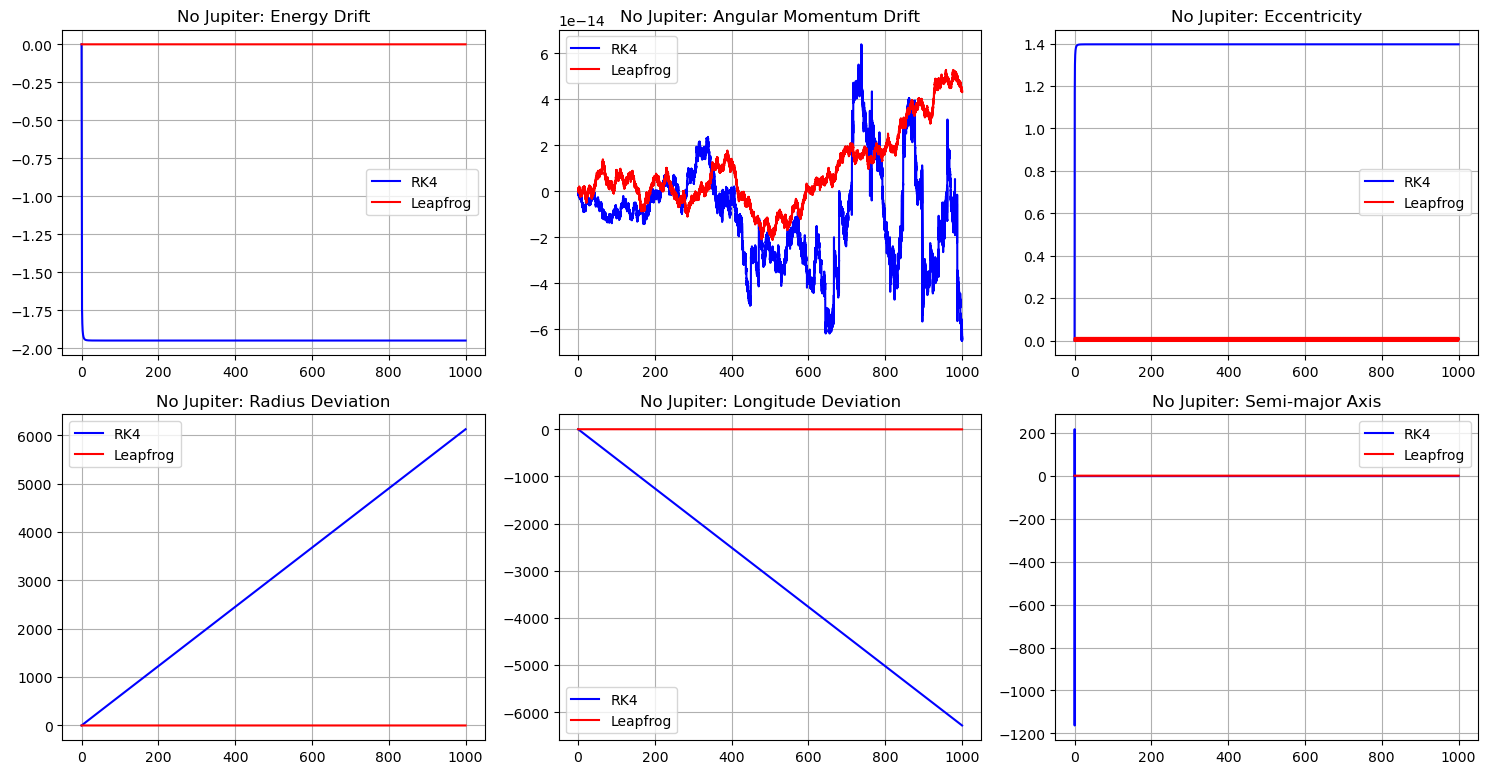

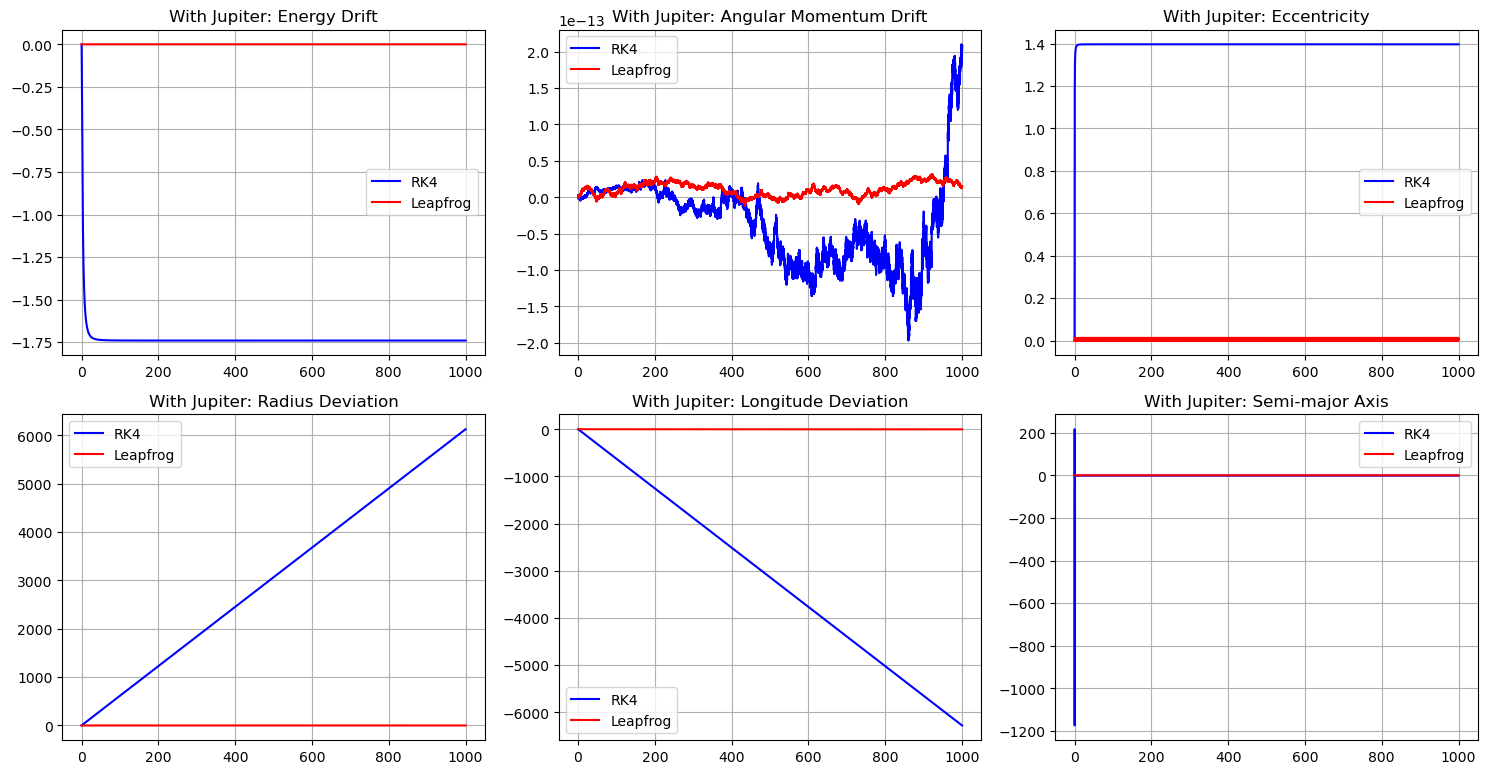

In [13]:
if __name__ == "__main__":
    data = main()

In [39]:
dt = 0.01*2
times = 100_000
steps_long = int(times / dt)

filename = "combined100k_data.txt"
data = np.loadtxt(filename)

time_years = data[:, 0] # time
ecc = data[:, 1] # eccentricity 
prec = data[:, 2] # precession
obl = data[:, 3] # obliquity
r_matched = data[:, 4] # calculated earth-sun distance
lon_matched = data[:, -1] # calculated longitude
years = len(time_years)

In [40]:
phi_65N = np.radians(65.0)

def daily_insolation(S0, r_AU, phi_rad, delta_rad):
    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)
    sin_delta = np.sin(delta_rad)
    cos_delta = np.cos(delta_rad)
    h0 = np.arccos(np.clip(-np.tan(phi_rad) * np.tan(delta_rad), -1, 1))
    Q = (S0 / np.pi) * (1.0 / r_AU**2) * (h0 * sin_phi * sin_delta + cos_phi * cos_delta * np.sin(h0))
    return Q

In [41]:
Q_summer = np.zeros_like(time_years)
for i in range(0,years):
    r_solstice = (1 - ecc[i]**2) / (1 + ecc[i] * np.cos(np.pi/2 - lon_matched[i]))
    delta_solstice = np.arcsin(np.sin(obl[i]) * np.sin(np.pi/2))
    Q_summer[i] = daily_insolation(S0, r_solstice, phi_65N, delta_solstice)

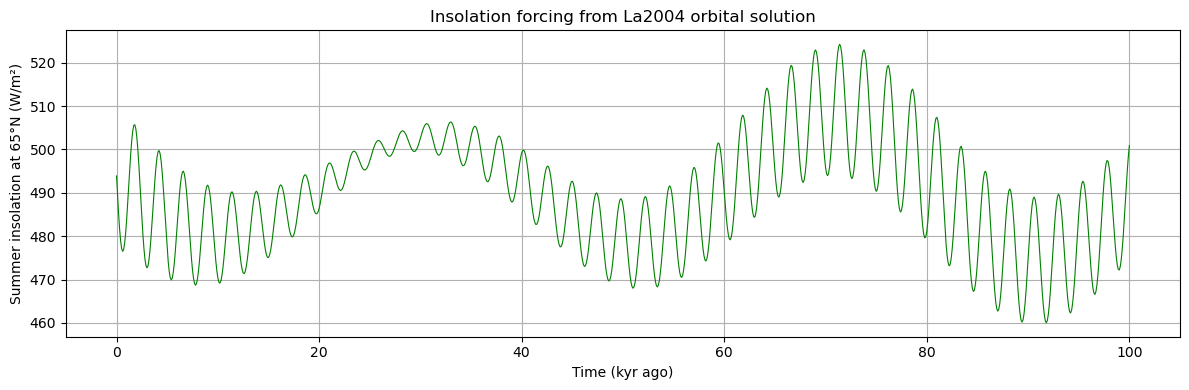

In [42]:
# show how summer insolation at 65°N changes over time due to orbital variations
plt.figure(figsize=(12, 4))
plt.plot(time_years/1000, Q_summer, 'g-', linewidth=0.8)
plt.xlabel('Time (kyr ago)')
plt.ylabel('Summer insolation at 65°N (W/m²)')
plt.title('Insolation forcing from our orbital solution')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
# Fourier analysis (use detrended data)
Q_detrend = detrend(Q_summer)
n = len(Q_detrend)
dt_yr = 1000.0 
freq = rfftfreq(n, d=dt_yr)          # 1/year
power = np.abs(rfft(Q_detrend))**2
period_kyr = 1.0 / (freq * 1000)     # convert to kyr

/var/folders/_z/81k1k6yj3cn2nxpkhrjw_ymm0000gn/T/ipykernel_11719/3456117702.py:7: RuntimeWarning: divide by zero encountered in divide
  period_kyr = 1.0 / (freq * 1000)     # convert to kyr


In [ ]:
plt.figure(figsize=(10, 5))
plt.semilogy(period_kyr, power, 'b-')
plt.xlim(10, 500)
plt.xlabel('Period (kyr)')
plt.ylabel('Power')     
plt.title('Power Spectrum of Summer Insolation at 65°N')
plt.axvline(23, color='r', linestyle='--', label='23 kyr (precession)')
plt.axvline(41, color='g', linestyle='--', label='41 kyr (obliquity)')
plt.axvline(100, color='k', linestyle='--', label='100 kyr (eccentricity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Find dominant periods in the power spectrum (should peak at ~23, 41, 100 kyr)
peaks, _ = find_peaks(power, height=np.max(power)*0.1)
dom_periods = period_kyr[peaks]
dom_power = power[peaks]
sorted_idx = np.argsort(dom_power)[::-1]
print("Dominant periods (kyr):", dom_periods[sorted_idx][:5])

In [ ]:
# Instead of Q_detrend, use the eccentricity data directly to see 100kyr peak (Laskar 2004 data) -- ice age!
ecc_detrend = detrend(ecc) 
power_ecc = np.abs(rfft(ecc_detrend))**2

plt.figure()
plt.semilogy(period_kyr, power_ecc)
plt.xlim(10, 200)
plt.axvline(100, color='k', linestyle='--', label='100 kyr (eccentricity)')
plt.legend()
plt.title('Power Spectrum of Eccentricity')
plt.show()

In [ ]:
# compare simulated eccentricity with Laskar 2004 data

dt = 0.01 
steps_long = int(100_000 / dt)

# Leapfrog simulation
time_sim_kyr = (np.arange(len(ecc_lf_sim)) * dt) / 1000.0

# Filter Laskar data to the first 100kyr to match
mask = t_kyr <= 100
t_laskar_filtered = t_kyr[mask]
ecc_laskar_filtered = ecc[mask]

# 1. Calculate a moving average to smooth the 'Jupiter noise'
# We want to average over roughly 500-1000 years to see the long-term trend
window_size = int(1000 / dt)  # 1000 year window
ecc_smoothed = np.convolve(ecc_lf_sim, np.ones(window_size)/window_size, mode='same')

# 2. Downsample for plotting (taking every 100th point for speed)
skip = 100
time_plot = time_sim_kyr[::skip]
ecc_plot = ecc_smoothed[::skip]

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot smoothed Simulated Data
ax[0].plot(time_plot, ecc_plot, color='red', label='Simulated (1kyr Moving Average)', linewidth=1.5)
ax[0].set_ylabel('Eccentricity')
ax[0].set_title('Earth Eccentricity: N-Body Simulation (Jupiter effects smoothed)')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Plot Laskar Data
ax[1].plot(t_laskar_filtered, ecc_laskar_filtered, color='black', label='Laskar 2004 (Reference)', linewidth=1)
ax[1].set_ylabel('Eccentricity')
ax[1].set_xlabel('Time (kyr)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()